# Multi-Factor Long-Short Equity Strategy — Walkthrough

End-to-end run of the pipeline: data → factors → portfolio → backtest → metrics → figures.

All factors are computed **point-in-time** (data ≤ rebalance date) and the book is rebalanced
monthly, dollar-neutral, with costs charged on turnover. See `README.md` for the full write-up.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import pandas as pd
pd.set_option('display.width', 160, 'display.max_columns', 20)

from data_loader import load_prices, to_month_end, load_benchmark
from factors import factor_scores
from portfolio import build_all_panels, rebalance_dates
from backtest import run_strategy, COST_BPS
from metrics import attribution
import analysis

## 1. Data
Daily adjusted close for the Nifty 100 universe (cached in `data/prices.csv`).

In [2]:
daily = load_prices()
monthly = to_month_end(daily)
bench = load_benchmark()
print('daily', daily.shape, daily.index.min().date(), '->', daily.index.max().date())
print('monthly', monthly.shape)
daily.iloc[:3, :5]

daily (3347, 98) 2011-06-01 -> 2024-12-30
monthly (163, 98)


,ABBOTINDIA,ACC,ADANIENT,ADANIPORTS,ADANIPOWER
Date,,,,,
2011-06-01,1222.407959,863.735535,81.886810,151.923111,23.110001
2011-06-02,1221.000244,854.922791,80.740715,149.375671,23.000000
2011-06-03,1208.329712,851.199158,79.182571,149.190414,22.730000


## 2. Factor scores at one rebalance date (point-in-time)
Oriented z-scores: higher = long. Note the late-IPO names get NaN where they lack history.

In [3]:
asof = rebalance_dates(monthly)[36]
scores = factor_scores(daily, monthly, asof)
print('as-of:', asof.date())
scores.sort_values('composite', ascending=False).head(8).round(2)

as-of: 2020-01-31


,momentum,low_vol,value,composite
HDFCLIFE,2.22,0.41,NaN,1.31
SBILIFE,1.93,0.50,NaN,1.22
ICICIPRULI,2.24,-0.18,NaN,1.03
ICICIGI,1.78,0.09,NaN,0.93
ABBOTINDIA,1.97,0.87,-0.54,0.76
BAJAJ-AUTO,0.51,1.23,0.47,0.74
ICICIBANK,1.36,0.33,0.46,0.72
BHARTIARTL,1.92,-0.64,0.81,0.70


## 3. Backtest the composite and each standalone factor
Net of costs, vs the Nifty 100 benchmark.

In [4]:
table, net_df, factor_corr, hedged = attribution(daily, monthly, bench)
table.round(3)   # includes composite_hedged (point-in-time beta-neutral overlay)

,ann_return_net,ann_vol_net,sharpe_net,sharpe_gross,cost_drag_sharpe,sortino_net,max_dd_net,calmar_net,alpha_ann,beta,info_ratio,avg_turnover,total_cost
strategy,,,,,,,,,,,,,
momentum,0.024,0.156,0.230,0.299,0.068,0.147,-0.414,0.058,0.069,-0.227,0.454,0.445,0.085
low_vol,-0.113,0.211,-0.457,-0.436,0.021,-0.513,-0.690,-0.164,0.006,-0.714,0.036,0.183,0.035
value,-0.018,0.154,-0.040,-0.001,0.039,-0.116,-0.512,-0.035,0.011,-0.120,0.072,0.251,0.048
composite,-0.081,0.200,-0.319,-0.271,0.049,-0.373,-0.609,-0.134,0.031,-0.660,0.185,0.406,0.077
composite_hedged,-0.023,0.163,-0.057,NaN,NaN,-0.126,-0.463,-0.049,0.007,-0.114,0.044,0.406,0.085
benchmark_N100,0.138,0.167,0.864,0.864,0.000,0.805,-0.288,0.478,0.000,1.000,NaN,NaN,NaN


In [5]:
print('Inter-factor correlation of standalone NET returns:')
factor_corr.round(2)

Inter-factor correlation of standalone NET returns:


,momentum,low_vol,value
momentum,1.00,0.25,0.04
low_vol,0.25,1.00,-0.13
value,0.04,-0.13,1.00


## 4. Figures
Regenerate the deliverable charts into `results/` and the Information Coefficient study.

In [6]:
results, net_df, bench_ret, bench_equity = analysis.run_all(daily, monthly, bench)
from metrics import summarize, RESULTS_DIR
tbl = pd.DataFrame([summarize(n, results[n], bench_ret) for n in analysis.SIGNALS]).set_index('strategy')

analysis.plot_equity_curves(results, bench_equity, os.path.join(RESULTS_DIR, 'equity_curves.png'))
analysis.plot_attribution(tbl, os.path.join(RESULTS_DIR, 'factor_attribution.png'))
analysis.plot_rolling_sharpe(net_df, bench_ret, os.path.join(RESULTS_DIR, 'rolling_sharpe.png'))

ic_ts, decay = analysis.compute_ic(daily, monthly)
analysis.plot_ic(ic_ts, decay, os.path.join(RESULTS_DIR, 'ic_analysis.png'))
print('Mean 1m IC:'); print(ic_ts.mean().round(3))
print('\nSaved figures to results/.')

Mean 1m IC:
momentum    0.020
low_vol    -0.010
value      -0.006
dtype: float64

Saved figures to results/.


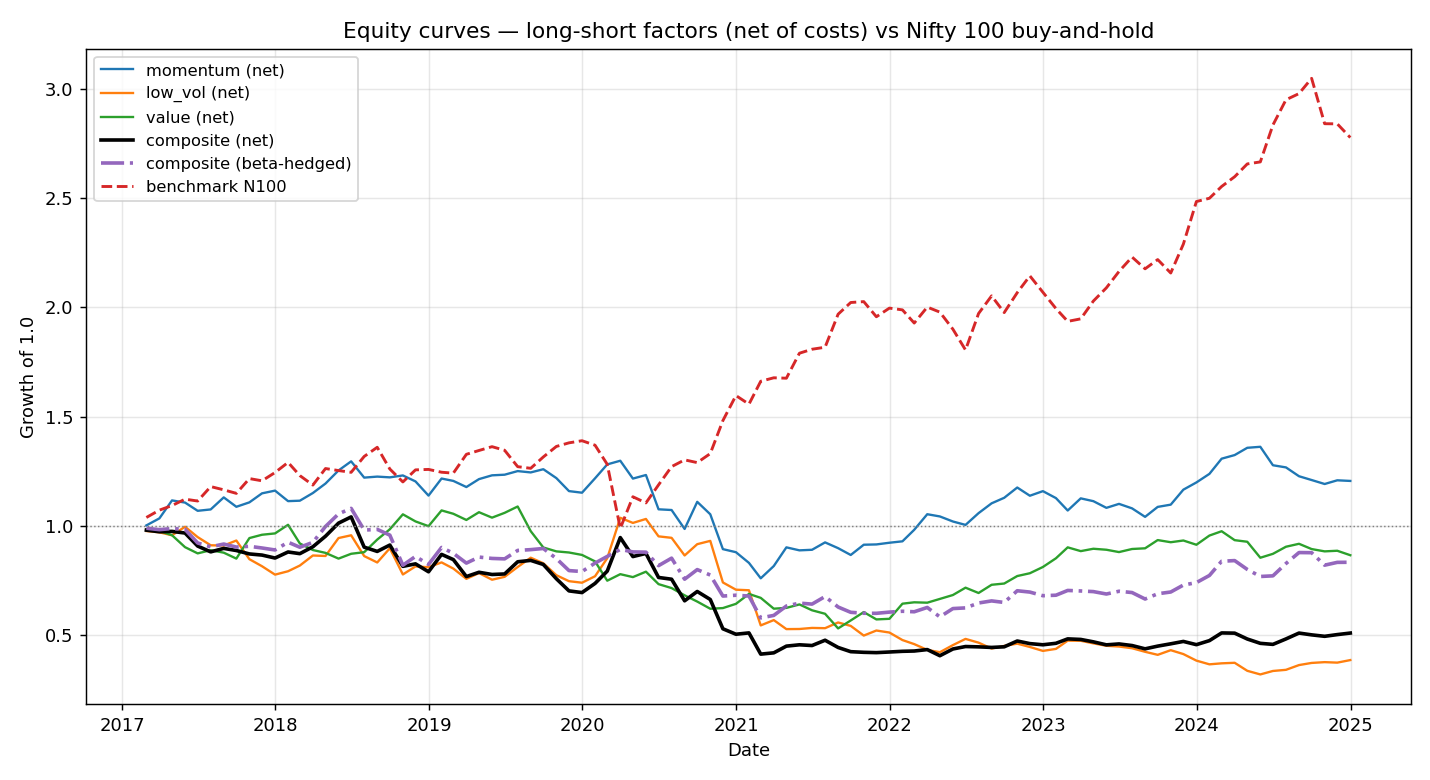

In [7]:
from IPython.display import Image
Image(filename=os.path.join(RESULTS_DIR, 'equity_curves.png'))

## Takeaway
The market-neutral book lost money over 2017–2024. A static full-sample regression flatters it
(+3.1% alpha, beta −0.66), but the **point-in-time beta-neutral overlay** tells the honest story:
once the time-varying short-beta tilt (from the low-vol leg) is hedged month-by-month, the residual
alpha is only **+0.7%** and the strategy is approximately **flat** (Sharpe −0.06), with much lower
vol and drawdown. The lesson: the apparent alpha was largely an artifact of a single static beta;
properly hedged, this factor blend did not generate alpha in this sample. Honest, fully attributed.